<a href="https://colab.research.google.com/github/4xuanzhou/GIS/blob/main/ps0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Community Health Assessment of New Jersey Communities Experiencing Compressor Station Construction or Expansion

The project aims to assess community health using data from CDC PLACES, with particular attention to health outcomes that may be relevant to environmental exposures associated with the proposed natural-gas Compressor Station 206 in Somerset County and the expansion of Station 325 in Sussex County.

Previous studies conducted in the Marcellus Shale region have found associations between exposure to unconventional natural gas development and adverse health outcomes, including increased risk of asthma exacerbations (Rasmussen et al., 2016) and psychological symptoms such as depression and anxiety (Blinn et al., 2020). Therefore, the expansion of Station 325 in 2023 may be associated with changes in health outcomes in Sussex County and surrounding communities, while the construction of Station 206 in Somerset County, anticipated by the end of 2027, may present potential health challenges for Somerset and surrounding communities. Examining existing health outcomes in Sussex County and surrounding communities could provide a useful case example, while assessing current health outcomes in Somerset County and surrounding communities could establish a baseline for future monitoring.

Findings from this project will inform evidence-based recommendations for tracking community health and health disparities at the neighborhood level in Somerset County and surrounding communities as the Station 206 project progresses. Given the project background, North and Central New Jersey will be the primary area of interest.

#### Unit of Analysis

The unit of analysis for this project is the census tract. CDC PLACES provides health data at the census-tract level (Centers for Disease Control and Prevention, 2025). Census tracts were selected because they allow for a more granular assessment of health disparities among neighborhoods surrounding the compressor stations. County-level data are not essential to this project because health outcomes potentially associated with compressor-station exposure may be diluted when aggregated across a large geographic area.

#### Research Questions

1. Is the 2023 expansion of Compressor Station 325 associated with changes in the prevalence of asthma and mental distress in Sussex County and surrounding communities?
2. Do communities located closer to Compressor Station 325 experience greater changes in the prevalence of asthma and mental distress following the expansion?
3. Based on evidence from the Station 325 case example, what recommendations can be made for establishing a baseline and monitoring community health and health disparities in Somerset County and surrounding communities as Compressor Station 206 progresses toward construction?

#### Hypotheses

1. The 2023 expansion of Compressor Station 325 is associated with an increase in the prevalence of asthma and mental distress in Sussex County and surrounding communities.
2. Communities located closer to Compressor Station 325 experience greater increases in the prevalence of asthma and mental distress following the 2023 expansion.


In [18]:
%%capture
#!pip install geopandas #==1.0.1
!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [19]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [20]:
#!python --version
gpd.__version__

'1.1.4'

In [21]:
import zipfile # Added: Import zipfile module

! wget -q -O nj0.zip https://github.com/4xuanzhou/GIS/raw/refs/heads/main/tl_2025_34_tract.zip
zip_ref = zipfile.ZipFile('nj0.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
!ls #see what we got

nj0=gpd.read_file('tl_2025_34_tract.shp') #load the shapefile with gpd as nj0


nj0.zip		      tl_2025_34_tract.prj
sample_data	      tl_2025_34_tract.shp
somerset-county.zip   tl_2025_34_tract.shp.ea.iso.xml
tl_2025_34_tract.cpg  tl_2025_34_tract.shp.iso.xml
tl_2025_34_tract.dbf  tl_2025_34_tract.shx


In [22]:
# Make the map of NJ
# Not interested in South Jersey,
# so I will filter in the next steps and then plot Central and North Jersey
# nj0.plot()

A map of North and Central New Jersey is shown below.

<Axes: >

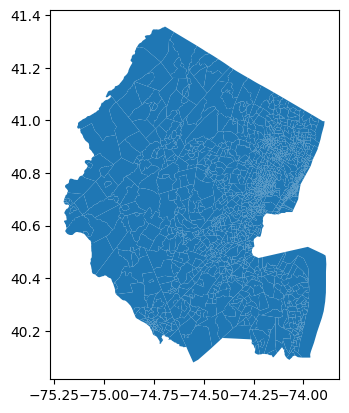

In [23]:


# Define the lists of counties for North and Central Jersey
north_counties = ['Bergen', 'Essex', 'Hudson', 'Morris', 'Passaic', 'Sussex', 'Warren']
central_counties = ['Hunterdon', 'Mercer', 'Middlesex', 'Monmouth', 'Somerset', 'Union']

# Combine them to get the full region
north_central_counties = north_counties + central_counties

# Manually created mapping of county names to FIPS codes for New Jersey
# These FIPS codes are standard 2-digit codes for NJ counties (as strings)
nj_county_fips_mapping = {
    'Atlantic': '001', 'Bergen': '003', 'Burlington': '005', 'Camden': '007',
    'Cape May': '009', 'Cumberland': '011', 'Essex': '013', 'Gloucester': '015',
    'Hudson': '017', 'Hunterdon': '019', 'Mercer': '021', 'Middlesex': '023',
    'Monmouth': '025', 'Morris': '027', 'Ocean': '029', 'Passaic': '031',
    'Salem': '033', 'Somerset': '035', 'Sussex': '037', 'Union': '039',
    'Warren': '041'
}

# Get the FIPS codes for the North and Central counties
north_central_counties_fips = [
    nj_county_fips_mapping[county_name]
    for county_name in north_central_counties
    if county_name in nj_county_fips_mapping
]

# Filter the GeoDataFrame using COUNTYFP column and FIPS codes
filtered_map = nj0[nj0['COUNTYFP'].isin(north_central_counties_fips)]
filtered_map.plot()

County names and boundaries are added to the map.

I wonder whether air quality measures are worth including in this project, and whether these data are publicly available and credible.

I also wonder whether, if my project focuses on changes in health outcomes over several years, I need to create a map for every single year, or it would be more appropriate to show changes over time in one interactive map.

<Axes: >

<Axes: >

Text(-74.07420731666883, 40.959688875565085, 'Bergen')

Text(-74.24706618116038, 40.78721122770507, 'Essex')

Text(-74.07617761704539, 40.73075415654254, 'Hudson')

...

Text(-74.61633664417698, 40.563506904888555, 'Somerset')

Text(-74.69089205721333, 41.13930235415108, 'Sussex')

Text(-74.30822412882085, 40.659932641792054, 'Union')

Text(-74.99734934583265, 40.857148592460554, 'Warren')

Text(0.5, 1.0, 'North and Central New Jersey')

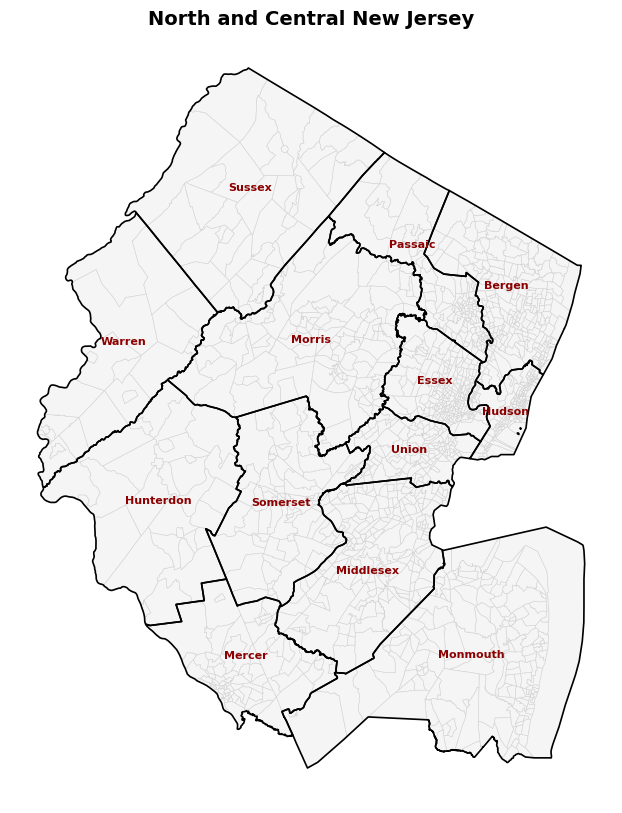

In [24]:
# I need to see the county names and boundaries (CLAUD helped write the code below)
# Dissolve tracts up to county level (one polygon per county)
county_map = filtered_map.dissolve(by='COUNTYFP')

# Make a 10×10 inch square figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the tract-level polygons (thin, light lines)
filtered_map.plot(ax=ax, color='whitesmoke', edgecolor='lightgray', linewidth=0.4)

# Overlay county boundaries (thicker, darker lines) so they stand out
county_map.boundary.plot(ax=ax, color='black', linewidth=1.2)

# Add county name labels at each county's centroid
# Use the global nj_county_fips_mapping for consistency and reverse it to get fips_to_name
fips_to_name = {fips: name for name, fips in nj_county_fips_mapping.items() if fips in north_central_counties_fips}

for fips, row in county_map.iterrows():
    centroid = row.geometry.centroid
    name = fips_to_name.get(fips, fips) # Use .get() with default for safety
    ax.annotate(
        name,
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=8, fontweight='bold', color='darkred'
    )
# Add title
ax.set_title("North and Central New Jersey", fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.show()

#### References

Blinn, H. N., Utz, R. M., Greiner, L. H., & Brown, D. R. (2020). Exposure assessment of adults living near unconventional oil and natural gas development and reported health symptoms in southwest Pennsylvania, USA. *PLOS ONE, 15*(8), e0237325. https://doi.org/10.1371/journal.pone.0237325

Centers for Disease Control and Prevention. (2025). *PLACES: Census tract data (GIS friendly format), 2025 release *[Data set]. https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data

Rasmussen, S. G., Ogburn, E. L., McCormack, M., Casey, J. A., Bandeen-Roche, K., Mercer, D. G., & Schwartz, B. S. (2016). Association between unconventional natural gas development in the Marcellus Shale and asthma exacerbations. *JAMA Internal Medicine, 176*(9), 1334–1343. https://doi.org/10.1001/jamainternmed.2016.2436